# RecipeIQ — Roadmap

### PHASE 0 → Data Audit & Reproducible Pipeline

### PHASE 1 → EDA + Feature Engineering

### PHASE 2 → Recommendation Baselines
- Popularity
- TF-IDF Content-Based
- Collaborative Filtering

### PHASE 3 → Deep Learning Recommenders
- Neural Collaborative Filtering (NCF)
- Hybrid NCF

### PHASE 4 → Recipe NLP / Semantic Intelligence
- TF-IDF
- Word2Vec / FastText
- Transformer Embeddings

### PHASE 5 → Two-Stage Recommendation
- Candidate Generation
- Two-Tower Retrieval
- Neural Ranking

### PHASE 6 → Advanced Recommendation
- Diversity
- Re-ranking
- Cold Start
- Explainability

### PHASE 7 → Supporting ML
- Preparation-Time Prediction
- Review Intelligence

### PHASE 8 → Production
- FastAPI
- Streamlit
- MLflow
- Deployment

# Phase 0: Data Audit

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [129]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
train = pd.read_csv("interactions_train.csv")
validation = pd.read_csv("interactions_validation.csv")
test = pd.read_csv("interactions_test.csv")

recipes = pd.read_csv("PP_recipes.csv")
users = pd.read_csv("PP_users.csv")

In [4]:
print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)
print("Recipes:", recipes.shape)
print("Users:", users.shape)

Train: (698901, 6)
Validation: (7023, 6)
Test: (12455, 6)
Recipes: (178265, 8)
Users: (25076, 6)


In [5]:
train.head()

,user_id,recipe_id,date,rating,u,i
0,2046,4684,2000-02-25,5.0,22095,44367
1,2046,517,2000-02-25,5.0,22095,87844
2,1773,7435,2000-03-13,5.0,24732,138181
3,1773,278,2000-03-13,4.0,24732,93054
4,2046,3431,2000-04-07,5.0,22095,101723


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 698901 entries, 0 to 698900
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   user_id    698901 non-null  int64  
 1   recipe_id  698901 non-null  int64  
 2   date       698901 non-null  object 
 3   rating     698901 non-null  float64
 4   u          698901 non-null  int64  
 5   i          698901 non-null  int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 32.0+ MB


In [7]:
train[["user_id", "u"]].drop_duplicates().head()

,user_id,u
0,2046,22095
2,1773,24732
6,2312,1674
10,2625,20667
12,2999,19047


In [8]:
train[["recipe_id", "i"]].drop_duplicates().head()

,recipe_id,i
0,4684,44367
1,517,87844
2,7435,138181
3,278,93054
4,3431,101723


In [9]:
print(train["rating"].value_counts().sort_index())
print(validation["rating"].value_counts().sort_index())
print(test["rating"].value_counts().sort_index())

rating
0.0     16957
1.0      3341
2.0      6852
3.0     25781
4.0    127402
5.0    518568
Name: count, dtype: int64
rating
0.0     356
1.0     132
2.0     173
3.0     462
4.0    1637
5.0    4263
Name: count, dtype: int64
rating
0.0     687
1.0     249
2.0     311
3.0     815
4.0    2807
5.0    7586
Name: count, dtype: int64


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [11]:
DATA_DIR = Path(r"C:\Users\Mastm\OneDrive\Documents\AnC Essentials\RecipeIQ")

train = pd.read_csv(DATA_DIR / "interactions_train.csv")
validation = pd.read_csv(DATA_DIR / "interactions_validation.csv")
test = pd.read_csv(DATA_DIR / "interactions_test.csv")

# Load only the columns needed for Phase 0
recipes = pd.read_csv(
    DATA_DIR / "PP_recipes.csv",
    usecols=["id", "i"]
)

users = pd.read_csv(
    DATA_DIR / "PP_users.csv",
    usecols=["u"]
)

print("✅ Datasets loaded successfully")

✅ Datasets loaded successfully


In [12]:
print("Train      :", train.shape)
print("Validation :", validation.shape)
print("Test       :", test.shape)
print("Recipes    :", recipes.shape)
print("Users      :", users.shape)

Train      : (698901, 6)
Validation : (7023, 6)
Test       : (12455, 6)
Recipes    : (178265, 2)
Users      : (25076, 1)


In [13]:
display(train.head())

,user_id,recipe_id,date,rating,u,i
0,2046,4684,25-02-2000,5,22095,44367
1,2046,517,25-02-2000,5,22095,87844
2,1773,7435,13-03-2000,5,24732,138181
3,1773,278,13-03-2000,4,24732,93054
4,2046,3431,07-04-2000,5,22095,101723


In [14]:
print(train.columns.tolist())

['user_id', 'recipe_id', 'date', 'rating', 'u', 'i']


In [15]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 698901 entries, 0 to 698900
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   user_id    698901 non-null  int64 
 1   recipe_id  698901 non-null  int64 
 2   date       698901 non-null  object
 3   rating     698901 non-null  int64 
 4   u          698901 non-null  int64 
 5   i          698901 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 32.0+ MB


In [16]:
print("Recipes columns:", recipes.columns.tolist())

Recipes columns: ['id', 'i']


In [17]:
print("Users columns:", users.columns.tolist())

Users columns: ['u']


In [18]:
display(train[["user_id", "u"]].drop_duplicates().head(10))

,user_id,u
0,2046,22095
2,1773,24732
6,2312,1674
10,2625,20667
12,2999,19047
13,2178,6065
15,3794,12353
19,2695,9204
20,5523,7396
23,42189,17652


In [19]:
display(train[["recipe_id", "i"]].drop_duplicates().head(10))

,recipe_id,i
0,4684,44367
1,517,87844
2,7435,138181
3,278,93054
4,3431,101723
5,13307,134551
6,780,127175
7,51964,151793
8,1232,15498
9,4397,14380


In [20]:
# Check whether one user_id always maps to one u
user_mapping_check = (train.groupby("user_id")["u"].nunique())

# Check whether one recipe_id always maps to one i
recipe_mapping_check = (train.groupby("recipe_id")["i"].nunique())

print("Users with multiple u values:",(user_mapping_check > 1).sum())

print("Recipes with multiple i values:",(recipe_mapping_check > 1).sum())

Users with multiple u values: 0
Recipes with multiple i values: 0


In [21]:
print("Users in train but missing from PP_users:",len(set(train["u"]) - set(users["u"])))

print("Recipes in train but missing from PP_recipes:",len(set(train["i"]) - set(recipes["i"])))

Users in train but missing from PP_users: 0
Recipes in train but missing from PP_recipes: 0


In [22]:
split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Interactions": [len(train), len(validation), len(test)],
    "Unique Users": [train["u"].nunique(), validation["u"].nunique(), test["u"].nunique()],
    "Unique Recipes": [train["i"].nunique(), validation["i"].nunique(), test["i"].nunique()]
})

display(split_summary)

,Split,Interactions,Unique Users,Unique Recipes
0,Train,698901,25076,160901
1,Validation,7023,7023,6621
2,Test,12455,12455,11695


In [23]:
print("TRAIN RATINGS")
print(train["rating"].value_counts().sort_index())

print("\nVALIDATION RATINGS")
print(validation["rating"].value_counts().sort_index())

print("\nTEST RATINGS")
print(test["rating"].value_counts().sort_index())

TRAIN RATINGS
rating
0     16957
1      3341
2      6852
3     25781
4    127402
5    518568
Name: count, dtype: int64

VALIDATION RATINGS
rating
0.0     356
1.0     132
2.0     173
3.0     462
4.0    1637
5.0    4263
Name: count, dtype: int64

TEST RATINGS
rating
0.0     687
1.0     249
2.0     311
3.0     815
4.0    2807
5.0    7586
Name: count, dtype: int64


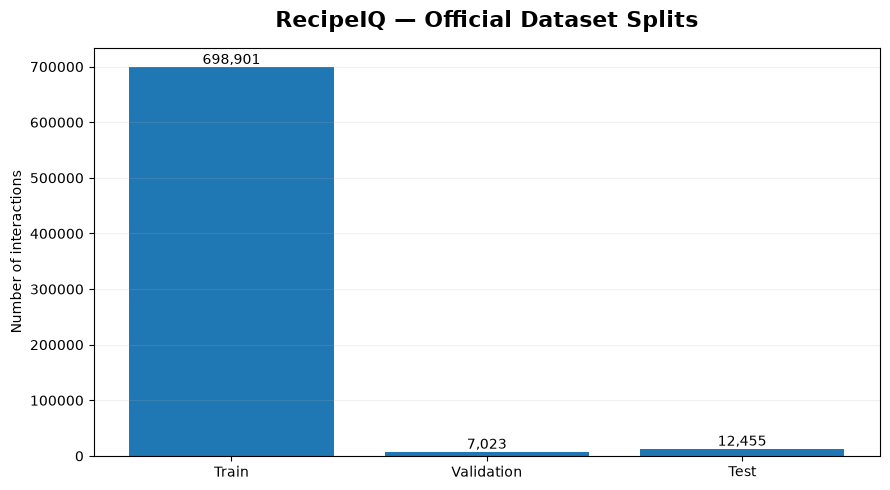

In [24]:
split_sizes = {"Train": len(train), "Validation": len(validation), "Test": len(test)}

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(split_sizes.keys(), split_sizes.values())

ax.set_title("RecipeIQ — Official Dataset Splits", fontsize=16, fontweight="bold", pad=15)

ax.set_ylabel("Number of interactions")
ax.grid(axis="y", alpha=0.18)

for bar, value in zip(bars, split_sizes.values()):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

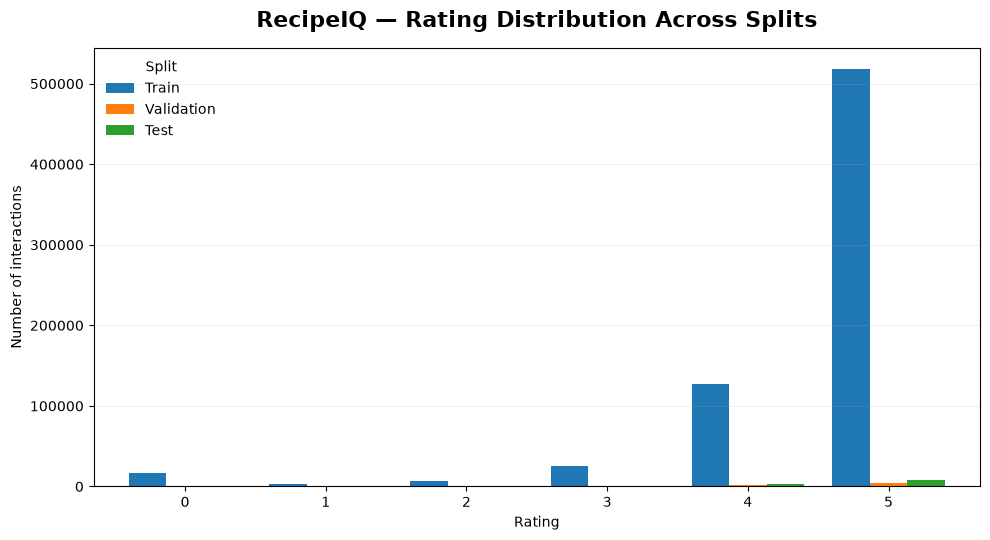

In [25]:
rating_counts = pd.DataFrame({
    "Train": train["rating"].value_counts().sort_index(),
    "Validation": validation["rating"].value_counts().sort_index(),
    "Test": test["rating"].value_counts().sort_index()
}).fillna(0)

ax = rating_counts.plot(
    kind="bar",
    figsize=(10, 5.5),
    width=0.8
)

ax.set_title("RecipeIQ — Rating Distribution Across Splits", fontsize=16, fontweight="bold", pad=15)

ax.set_xlabel("Rating")
ax.set_ylabel("Number of interactions")

ax.grid(axis="y", alpha=0.18)
ax.legend(title="Split", frameon=False)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [26]:
train_pairs = set(zip(train["u"], train["i"]))
validation_pairs = set(zip(validation["u"], validation["i"]))
test_pairs = set(zip(test["u"], test["i"]))

print("Train ∩ Validation:", len(train_pairs & validation_pairs))
print("Train ∩ Test:", len(train_pairs & test_pairs))
print("Validation ∩ Test:", len(validation_pairs & test_pairs))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [27]:
print("Validation interactions:", len(validation))
print("Unique validation users:", validation["u"].nunique())

print("\nTest interactions:", len(test))
print("Unique test users:", test["u"].nunique())

Validation interactions: 7023
Unique validation users: 7023

Test interactions: 12455
Unique test users: 12455


In [28]:
print(
    "Duplicate (user, recipe) pairs in Train:",
    train.duplicated(["u", "i"]).sum()
)

print(
    "Duplicate (user, recipe) pairs in Validation:",
    validation.duplicated(["u", "i"]).sum()
)

print(
    "Duplicate (user, recipe) pairs in Test:",
    test.duplicated(["u", "i"]).sum()
)

Duplicate (user, recipe) pairs in Train: 0
Duplicate (user, recipe) pairs in Validation: 0
Duplicate (user, recipe) pairs in Test: 0


# Phase 1.1: EDA

In [29]:
from pathlib import Path

DATA_DIR = Path(r"C:\Users\Mastm\OneDrive\Documents\AnC Essentials\RecipeIQ")

print(DATA_DIR)

C:\Users\Mastm\OneDrive\Documents\AnC Essentials\RecipeIQ


In [30]:
raw_recipes = pd.read_csv(DATA_DIR / "RAW_recipes.csv", engine="python",  on_bad_lines="skip")

print("Shape:", raw_recipes.shape)

Shape: (231637, 12)


In [31]:
raw_recipes.head()

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...","[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8


In [32]:
raw_recipes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231637 entries, 0 to 231636
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   name            231636 non-null  object
 1   id              231637 non-null  int64 
 2   minutes         231637 non-null  int64 
 3   contributor_id  231637 non-null  int64 
 4   submitted       231637 non-null  object
 5   tags            231637 non-null  object
 6   nutrition       231637 non-null  object
 7   n_steps         231637 non-null  int64 
 8   steps           231637 non-null  object
 9   description     226658 non-null  object
 10  ingredients     231637 non-null  object
 11  n_ingredients   231637 non-null  int64 
dtypes: int64(5), object(7)
memory usage: 21.2+ MB


In [33]:
raw_recipes.columns.tolist()

['name',
 'id',
 'minutes',
 'contributor_id',
 'submitted',
 'tags',
 'nutrition',
 'n_steps',
 'steps',
 'description',
 'ingredients',
 'n_ingredients']

In [34]:
raw_recipes.isna().sum().sort_values(ascending=False)

description       4979
name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
ingredients          0
n_ingredients        0
dtype: int64

In [35]:
raw_recipes.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,231636,230185,crock pot lemon garlic chicken,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id,231637.0,NaN,NaN,NaN,222014.708984,141206.635626,38.0,99944.0,207249.0,333816.0,537716.0
minutes,231637.0,NaN,NaN,NaN,9398.546009,4461963.038858,0.0,20.0,40.0,65.0,2147483647.0
contributor_id,231637.0,NaN,NaN,NaN,5534885.113838,99791408.213893,27.0,56905.0,173614.0,398275.0,2002289981.0
submitted,231637,5090,2000-03-06,470,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tags,231637,209115,"['15-minutes-or-less', 'time-to-make', 'course...",397,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nutrition,231637,229318,"[69.4, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_steps,231637.0,NaN,NaN,NaN,9.765499,5.995128,0.0,6.0,9.0,12.0,145.0
steps,231637,231074,['blend all ingredients until smooth'],20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,226658,222668,yum,153,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
print("Total recipes:", raw_recipes["id"].nunique())

Total recipes: 231637


In [37]:
print("Unique recipe names:", raw_recipes["name"].nunique())

Unique recipe names: 230185


In [38]:
print(raw_recipes["minutes"].describe())

count    2.316370e+05
mean     9.398546e+03
std      4.461963e+06
min      0.000000e+00
25%      2.000000e+01
50%      4.000000e+01
75%      6.500000e+01
max      2.147484e+09
Name: minutes, dtype: float64


In [39]:
print(raw_recipes["n_ingredients"].describe())

count    231637.000000
mean          9.051153
std           3.734796
min           1.000000
25%           6.000000
50%           9.000000
75%          11.000000
max          43.000000
Name: n_ingredients, dtype: float64


In [40]:
print(raw_recipes["n_steps"].describe())

count    231637.000000
mean          9.765499
std           5.995128
min           0.000000
25%           6.000000
50%           9.000000
75%          12.000000
max         145.000000
Name: n_steps, dtype: float64


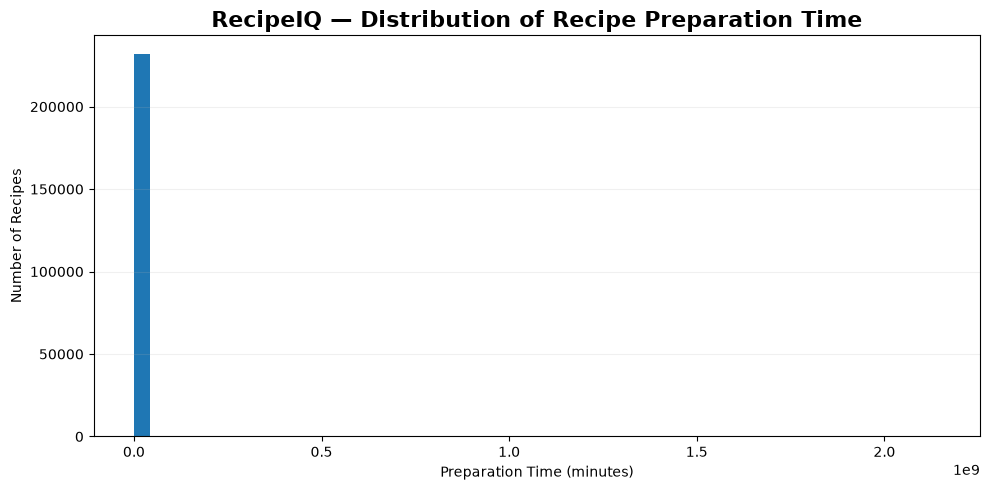

In [41]:
plt.figure(figsize=(10, 5))

plt.hist(
    raw_recipes["minutes"],
    bins=50
)

plt.title(
    "RecipeIQ — Distribution of Recipe Preparation Time",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Preparation Time (minutes)")
plt.ylabel("Number of Recipes")

plt.grid(axis="y", alpha=0.18)

plt.tight_layout()
plt.show()

In [42]:
raw_recipes["minutes"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 0.999])

0.500       40.00
0.750       65.00
0.900      135.00
0.950      255.00
0.990      903.92
0.999    10095.00
Name: minutes, dtype: float64

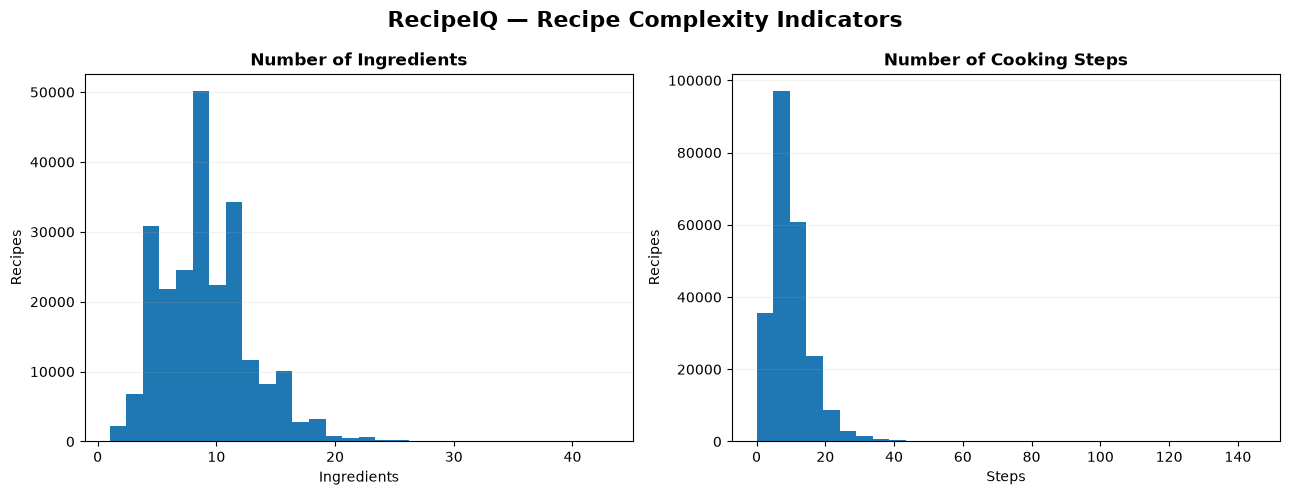

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(
    raw_recipes["n_ingredients"],
    bins=30
)

axes[0].set_title(
    "Number of Ingredients",
    fontweight="bold"
)

axes[0].set_xlabel("Ingredients")
axes[0].set_ylabel("Recipes")
axes[0].grid(axis="y", alpha=0.18)


axes[1].hist(
    raw_recipes["n_steps"],
    bins=30
)

axes[1].set_title(
    "Number of Cooking Steps",
    fontweight="bold"
)

axes[1].set_xlabel("Steps")
axes[1].set_ylabel("Recipes")
axes[1].grid(axis="y", alpha=0.18)

plt.suptitle(
    "RecipeIQ — Recipe Complexity Indicators",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [44]:
raw_recipes["nutrition"].head()

0         [51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]
1     [173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]
2    [269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]
3     [368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]
4     [352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]
Name: nutrition, dtype: object

In [45]:
print(raw_recipes["nutrition"].iloc[0])

[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]


In [46]:
print(type(raw_recipes["nutrition"].iloc[0]))

<class 'str'>


In [47]:
print("Recipes with 0 minutes:", (raw_recipes["minutes"] == 0).sum())

print(
    "Recipes with more than 24 hours:",
    (raw_recipes["minutes"] > 1440).sum()
)

print(
    "Recipes with more than 7 days:",
    (raw_recipes["minutes"] > 10080).sum()
)

print(
    "Recipes with extreme integer maximum:",
    (raw_recipes["minutes"] == raw_recipes["minutes"].max()).sum()
)

Recipes with 0 minutes: 1094
Recipes with more than 24 hours: 2000
Recipes with more than 7 days: 256
Recipes with extreme integer maximum: 1


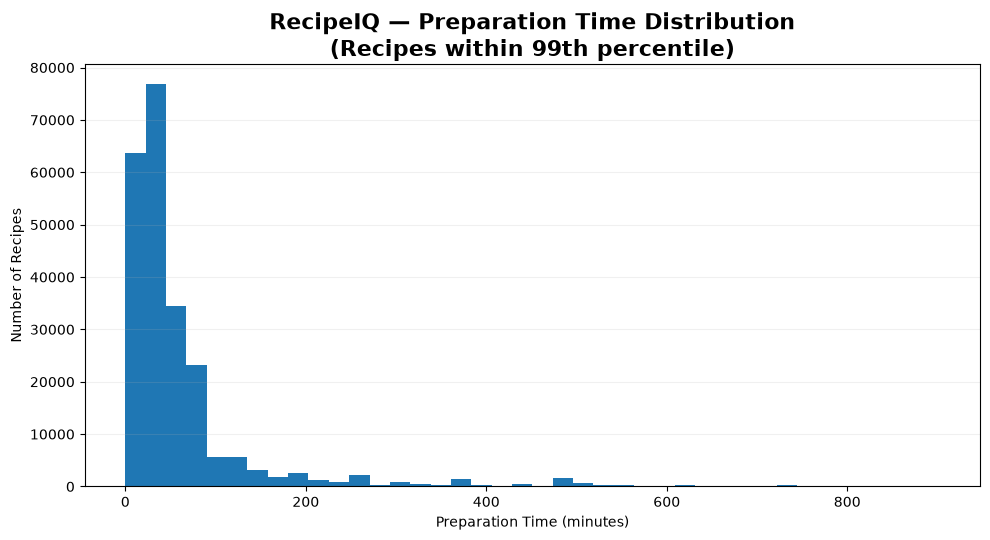

In [48]:
time_for_plot = raw_recipes.loc[
    raw_recipes["minutes"] <= raw_recipes["minutes"].quantile(0.99),
    "minutes"
]

plt.figure(figsize=(10, 5.5))

plt.hist(time_for_plot, bins=40)

plt.title(
    "RecipeIQ — Preparation Time Distribution\n(Recipes within 99th percentile)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Preparation Time (minutes)")
plt.ylabel("Number of Recipes")

plt.grid(axis="y", alpha=0.18)
plt.tight_layout()
plt.show()

In [49]:
complexity_corr = raw_recipes[
    ["minutes", "n_ingredients", "n_steps"]
].corr()

display(complexity_corr)

,minutes,n_ingredients,n_steps
minutes,1.000000,-0.000592,-0.000257
n_ingredients,-0.000592,1.000000,0.427705
n_steps,-0.000257,0.427705,1.000000


In [50]:
normal_time = raw_recipes[
    raw_recipes["minutes"] <= raw_recipes["minutes"].quantile(0.99)
].copy()

display(
    normal_time[
        ["minutes", "n_ingredients", "n_steps"]
    ].corr()
)

,minutes,n_ingredients,n_steps
minutes,1.000000,0.152140,0.145821
n_ingredients,0.152140,1.000000,0.430924
n_steps,0.145821,0.430924,1.000000


In [51]:
print(raw_recipes["nutrition"].head(10).to_string())

0                [51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]
1            [173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]
2           [269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]
3            [368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]
4            [352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]
5             [160.2, 10.0, 55.0, 3.0, 9.0, 20.0, 7.0]
6             [380.7, 53.0, 7.0, 24.0, 6.0, 24.0, 6.0]
7       [1109.5, 83.0, 378.0, 275.0, 96.0, 86.0, 36.0]
8    [4270.8, 254.0, 1306.0, 111.0, 127.0, 431.0, 2...
9    [2669.3, 160.0, 976.0, 107.0, 62.0, 310.0, 138.0]


In [52]:
print(raw_recipes["nutrition"].iloc[0])
print(type(raw_recipes["nutrition"].iloc[0]))

[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]
<class 'str'>


In [53]:
import ast

nutrition_example = ast.literal_eval(
    raw_recipes["nutrition"].iloc[0]
)

print(nutrition_example)
print(type(nutrition_example))
print("Number of values:", len(nutrition_example))

[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]
<class 'list'>
Number of values: 7


In [54]:
nutrition_lengths = raw_recipes["nutrition"].apply(
    lambda x: len(ast.literal_eval(x))
)

print(nutrition_lengths.value_counts().sort_index())

nutrition
7    231637
Name: count, dtype: int64


In [55]:
nutrition_columns = [
    "calories",
    "total_fat",
    "sugar",
    "sodium",
    "protein",
    "saturated_fat",
    "carbohydrates"
]

nutrition_data = pd.DataFrame(
    raw_recipes["nutrition"].apply(ast.literal_eval).tolist(),
    columns=nutrition_columns,
    index=raw_recipes.index
)

nutrition_data.head()

,calories,total_fat,sugar,sodium,protein,saturated_fat,carbohydrates
0,51.5,0.0,13.0,0.0,2.0,0.0,4.0
1,173.4,18.0,0.0,17.0,22.0,35.0,1.0
2,269.8,22.0,32.0,48.0,39.0,27.0,5.0
3,368.1,17.0,10.0,2.0,14.0,8.0,20.0
4,352.9,1.0,337.0,23.0,3.0,0.0,28.0


In [56]:
nutrition_data.describe().T

,count,mean,std,min,25%,50%,75%,max
calories,231637.0,473.942425,1189.711374,0.0,174.4,313.4,519.7,434360.2
total_fat,231637.0,36.080700,77.798840,0.0,8.0,20.0,41.0,17183.0
sugar,231637.0,84.296865,800.080897,0.0,9.0,25.0,68.0,362729.0
sodium,231637.0,30.147485,131.961589,0.0,5.0,14.0,33.0,29338.0
protein,231637.0,34.681860,58.472480,0.0,7.0,18.0,51.0,6552.0
saturated_fat,231637.0,45.589150,98.235758,0.0,7.0,23.0,52.0,10395.0
carbohydrates,231637.0,15.560403,81.824560,0.0,4.0,9.0,16.0,36098.0


In [57]:
nutrition_data.isna().sum()

calories         0
total_fat        0
sugar            0
sodium           0
protein          0
saturated_fat    0
carbohydrates    0
dtype: int64

In [58]:
nutrition_data.describe().T[
    ["mean", "50%", "75%", "max"]
]

,mean,50%,75%,max
calories,473.942425,313.4,519.7,434360.2
total_fat,36.080700,20.0,41.0,17183.0
sugar,84.296865,25.0,68.0,362729.0
sodium,30.147485,14.0,33.0,29338.0
protein,34.681860,18.0,51.0,6552.0
saturated_fat,45.589150,23.0,52.0,10395.0
carbohydrates,15.560403,9.0,16.0,36098.0


In [59]:
print(raw_recipes["ingredients"].head(10).to_string())

0    ['winter squash', 'mexican seasoning', 'mixed ...
1    ['prepared pizza crust', 'sausage patty', 'egg...
2    ['ground beef', 'yellow onions', 'diced tomato...
3    ['spreadable cheese with garlic and herbs', 'n...
4    ['tomato juice', 'apple cider vinegar', 'sugar...
5    ['milk', 'vanilla ice cream', 'frozen apple ju...
6    ['fennel seeds', 'green olives', 'ripe olives'...
7    ['pork spareribs', 'soy sauce', 'fresh garlic'...
8    ['chocolate sandwich style cookies', 'chocolat...
9    ['sugar', 'unsalted butter', 'bananas', 'eggs'...


In [60]:
print(type(raw_recipes["ingredients"].iloc[0]))

<class 'str'>


In [61]:
ingredient_lengths = raw_recipes["ingredients"].apply(
    lambda x: len(ast.literal_eval(x))
)

print(ingredient_lengths.describe())

count    231637.000000
mean          9.051153
std           3.734796
min           1.000000
25%           6.000000
50%           9.000000
75%          11.000000
max          43.000000
Name: ingredients, dtype: float64


In [62]:
from collections import Counter

ingredient_counter = Counter()

for ingredients in raw_recipes["ingredients"]:
    ingredient_list = ast.literal_eval(ingredients)
    ingredient_counter.update(ingredient_list)

top_ingredients = pd.DataFrame(
    ingredient_counter.most_common(20),
    columns=["ingredient", "recipe_count"]
)

top_ingredients

,ingredient,recipe_count
0,salt,85746
1,butter,54975
2,sugar,44535
3,onion,39065
4,water,34914
5,eggs,33761
6,olive oil,32822
7,flour,26266
8,milk,25786
9,garlic cloves,25748


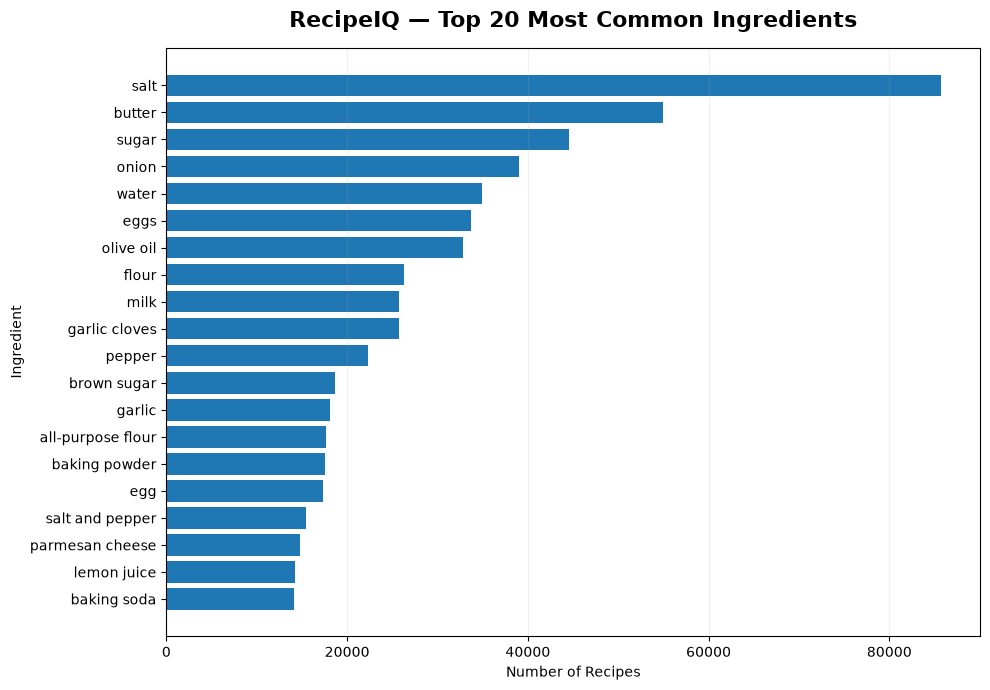

In [63]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_ingredients["ingredient"][::-1],
    top_ingredients["recipe_count"][::-1]
)

plt.title(
    "RecipeIQ — Top 20 Most Common Ingredients",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Recipes")
plt.ylabel("Ingredient")

plt.grid(axis="x", alpha=0.18)

plt.tight_layout()
plt.show()

In [64]:
print("Unique ingredients:", len(ingredient_counter))

print(
    "Average ingredients per recipe:",
    round(ingredient_lengths.mean(), 2)
)

print(
    "Median ingredients per recipe:",
    ingredient_lengths.median()
)

Unique ingredients: 14942
Average ingredients per recipe: 9.05
Median ingredients per recipe: 9.0


In [65]:
ingredient_frequency = pd.Series(
    ingredient_counter
).sort_values()

print("Ingredients appearing once:",
      (ingredient_frequency == 1).sum())

print("Ingredients appearing ≤ 5 times:",
      (ingredient_frequency <= 5).sum())

print("Ingredients appearing ≤ 10 times:",
      (ingredient_frequency <= 10).sum())

Ingredients appearing once: 3546
Ingredients appearing ≤ 5 times: 7489
Ingredients appearing ≤ 10 times: 9201


In [66]:
print(
    ingredient_frequency.describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

count    14942.000000
mean       140.314683
std       1341.349585
min          1.000000
25%          2.000000
50%          5.000000
75%         28.000000
90%        134.000000
95%        358.000000
99%       2243.800000
max      85746.000000
dtype: float64


In [67]:
print(raw_recipes["tags"].head(10).to_string())
print(type(raw_recipes["tags"].iloc[0]))

0    ['60-minutes-or-less', 'time-to-make', 'course...
1    ['30-minutes-or-less', 'time-to-make', 'course...
2    ['time-to-make', 'course', 'preparation', 'mai...
3    ['60-minutes-or-less', 'time-to-make', 'course...
4    ['weeknight', 'time-to-make', 'course', 'main-...
5    ['15-minutes-or-less', 'time-to-make', 'course...
6    ['15-minutes-or-less', 'time-to-make', 'course...
7    ['weeknight', 'time-to-make', 'course', 'main-...
8    ['weeknight', 'time-to-make', 'course', 'main-...
9    ['weeknight', 'time-to-make', 'course', 'main-...
<class 'str'>


In [68]:
tag_lengths = raw_recipes["tags"].apply(
    lambda x: len(ast.literal_eval(x))
)

print(tag_lengths.describe())

count    231637.000000
mean         17.880080
std           7.244332
min           1.000000
25%          13.000000
50%          17.000000
75%          22.000000
max          73.000000
Name: tags, dtype: float64


In [69]:
tag_counter = Counter()

for tags in raw_recipes["tags"]:
    tag_list = ast.literal_eval(tags)
    tag_counter.update(tag_list)

top_tags = pd.DataFrame(
    tag_counter.most_common(20),
    columns=["tag", "recipe_count"]
)

top_tags

,tag,recipe_count
0,preparation,230546
1,time-to-make,225326
2,course,218148
3,main-ingredient,170446
4,dietary,165091
5,easy,126062
6,occasion,114145
7,cuisine,91165
8,low-in-something,85776
9,main-dish,71786


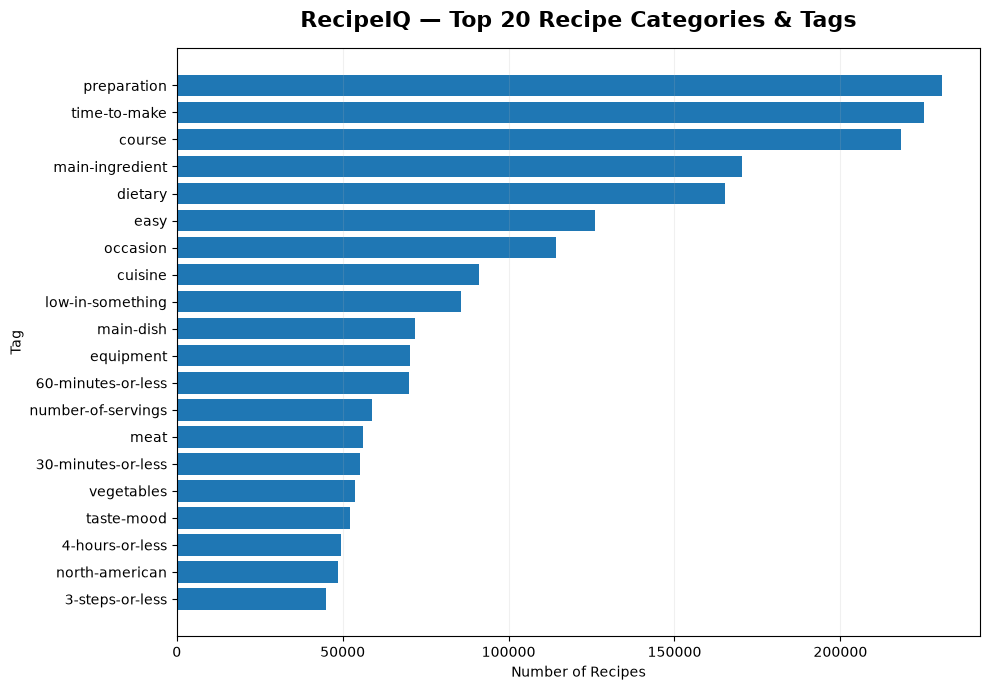

In [70]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_tags["tag"][::-1],
    top_tags["recipe_count"][::-1]
)

plt.title(
    "RecipeIQ — Top 20 Recipe Categories & Tags",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Recipes")
plt.ylabel("Tag")

plt.grid(axis="x", alpha=0.18)

plt.tight_layout()
plt.show()

In [71]:
print("Unique tags:", len(tag_counter))

tag_frequency = pd.Series(tag_counter).sort_values()

print("Tags appearing once:",
      (tag_frequency == 1).sum())

print("Tags appearing <= 5 times:",
      (tag_frequency <= 5).sum())

print("Tags appearing <= 10 times:",
      (tag_frequency <= 10).sum())

print("\nTag frequency distribution:")
print(
    tag_frequency.describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

Unique tags: 552
Tags appearing once: 44
Tags appearing <= 5 times: 56
Tags appearing <= 10 times: 64

Tag frequency distribution:
count       552.000000
mean       7503.057971
std       23358.831344
min           1.000000
25%          96.250000
50%         757.500000
75%        4240.500000
90%       18886.700000
95%       36001.100000
99%      119984.330000
max      230546.000000
dtype: float64


In [72]:
user_activity = train.groupby("u").size()

print(user_activity.describe())

count    25076.000000
mean        27.871311
std        122.729039
min          2.000000
25%          3.000000
50%          6.000000
75%         16.000000
max       6437.000000
dtype: float64


In [73]:
print("Most active users:")
display(
    user_activity.sort_values(ascending=False).head(10)
)

Most active users:


u
94     6437
275    4581
193    3656
241    3465
208    3338
130    2851
564    2798
164    2733
319    2602
267    2457
dtype: int64

In [74]:
print("Users with only 1 interaction:")
print((user_activity == 1).sum())

print("Users with ≤ 5 interactions:")
print((user_activity <= 5).sum())

print("Users with > 50 interactions:")
print((user_activity > 50).sum())

Users with only 1 interaction:
0
Users with ≤ 5 interactions:
11664
Users with > 50 interactions:
2249


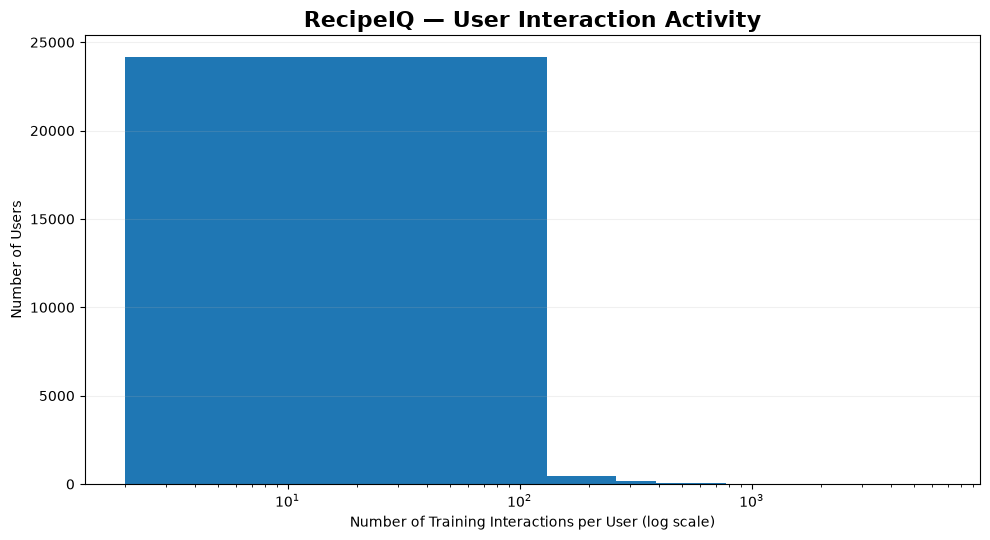

In [75]:
plt.figure(figsize=(10, 5.5))

plt.hist(
    user_activity,
    bins=50
)

plt.xscale("log")

plt.title(
    "RecipeIQ — User Interaction Activity",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Training Interactions per User (log scale)")
plt.ylabel("Number of Users")

plt.grid(axis="y", alpha=0.18)

plt.tight_layout()
plt.show()

In [76]:
recipe_popularity = train.groupby("i").size()

print(recipe_popularity.describe())

count    160901.000000
mean          4.343671
std          13.421461
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max        1091.000000
dtype: float64


In [77]:
print("Most popular recipes:")
display(
    recipe_popularity.sort_values(ascending=False).head(10)
)

Most popular recipes:


i
99787     1091
134610    1075
135961     897
117899     894
147374     787
52334      758
101819     738
37047      681
56425      677
127080     666
dtype: int64

In [78]:
print("Recipes with only 1 interaction:")
print((recipe_popularity == 1).sum())

print("Recipes with ≤ 5 interactions:")
print((recipe_popularity <= 5).sum())

print("Recipes with > 100 interactions:")
print((recipe_popularity > 100).sum())

Recipes with only 1 interaction:
66478
Recipes with ≤ 5 interactions:
133883
Recipes with > 100 interactions:
402


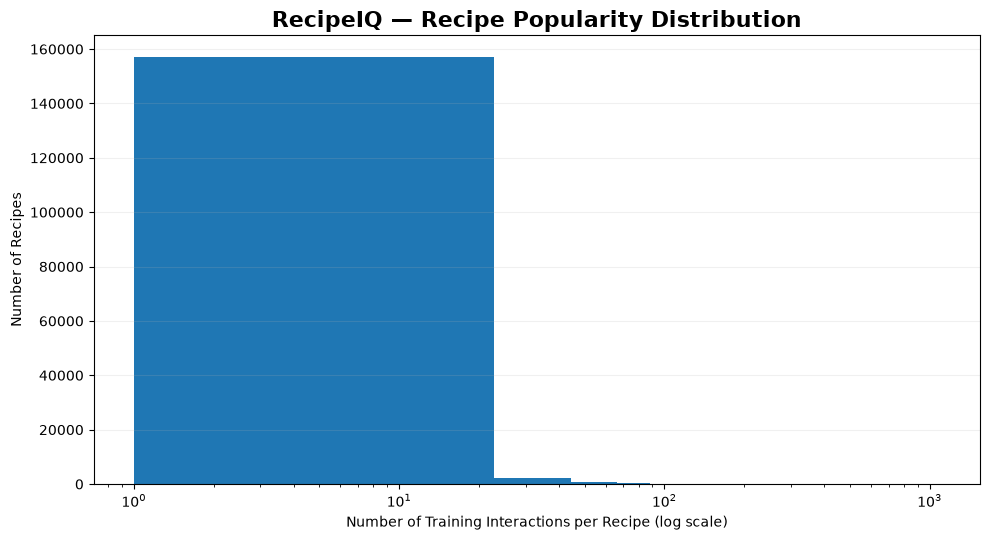

In [79]:
plt.figure(figsize=(10, 5.5))

plt.hist(
    recipe_popularity,
    bins=50
)

plt.xscale("log")

plt.title(
    "RecipeIQ — Recipe Popularity Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Training Interactions per Recipe (log scale)")
plt.ylabel("Number of Recipes")

plt.grid(axis="y", alpha=0.18)

plt.tight_layout()
plt.show()

In [80]:
user_activity = train.groupby("u").size()

print(user_activity.describe())

count    25076.000000
mean        27.871311
std        122.729039
min          2.000000
25%          3.000000
50%          6.000000
75%         16.000000
max       6437.000000
dtype: float64


In [81]:
print("Most active users:")
display(
    user_activity.sort_values(ascending=False).head(10)
)

Most active users:


u
94     6437
275    4581
193    3656
241    3465
208    3338
130    2851
564    2798
164    2733
319    2602
267    2457
dtype: int64

In [82]:
print("Users with only 1 interaction:",
      (user_activity == 1).sum())

print("Users with ≤ 5 interactions:",
      (user_activity <= 5).sum())

print("Users with > 50 interactions:",
      (user_activity > 50).sum())

Users with only 1 interaction: 0
Users with ≤ 5 interactions: 11664
Users with > 50 interactions: 2249


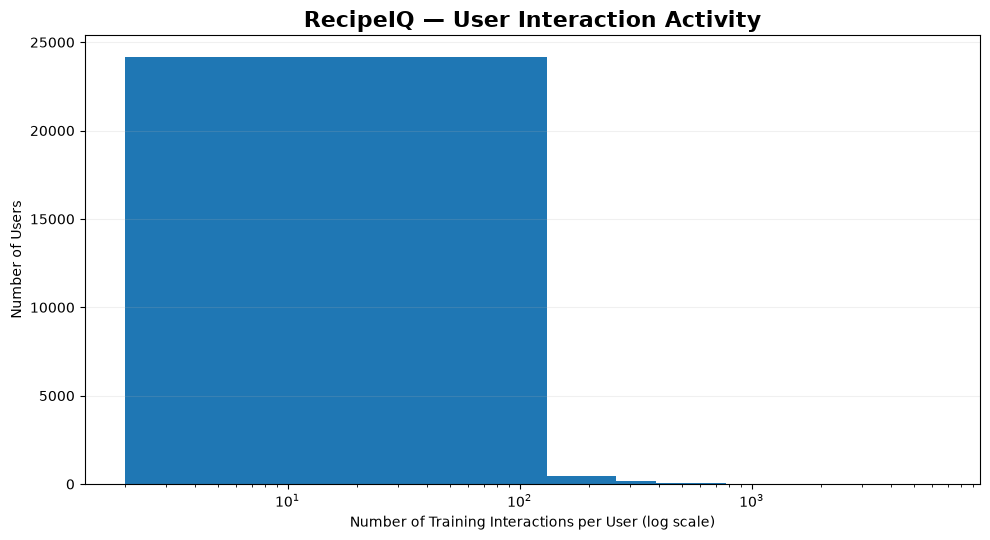

In [83]:
plt.figure(figsize=(10, 5.5))

plt.hist(user_activity, bins=50)

plt.xscale("log")

plt.title(
    "RecipeIQ — User Interaction Activity",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Training Interactions per User (log scale)")
plt.ylabel("Number of Users")

plt.grid(axis="y", alpha=0.18)

plt.tight_layout()
plt.show()

In [84]:
recipe_popularity = train.groupby("i").size()

print(recipe_popularity.describe())

count    160901.000000
mean          4.343671
std          13.421461
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max        1091.000000
dtype: float64


In [85]:
print("Most popular recipes:")
display(
    recipe_popularity.sort_values(ascending=False).head(10)
)

Most popular recipes:


i
99787     1091
134610    1075
135961     897
117899     894
147374     787
52334      758
101819     738
37047      681
56425      677
127080     666
dtype: int64

In [86]:
print("Recipes with only 1 interaction:",
      (recipe_popularity == 1).sum())

print("Recipes with ≤ 5 interactions:",
      (recipe_popularity <= 5).sum())

print("Recipes with > 100 interactions:",
      (recipe_popularity > 100).sum())

Recipes with only 1 interaction: 66478
Recipes with ≤ 5 interactions: 133883
Recipes with > 100 interactions: 402


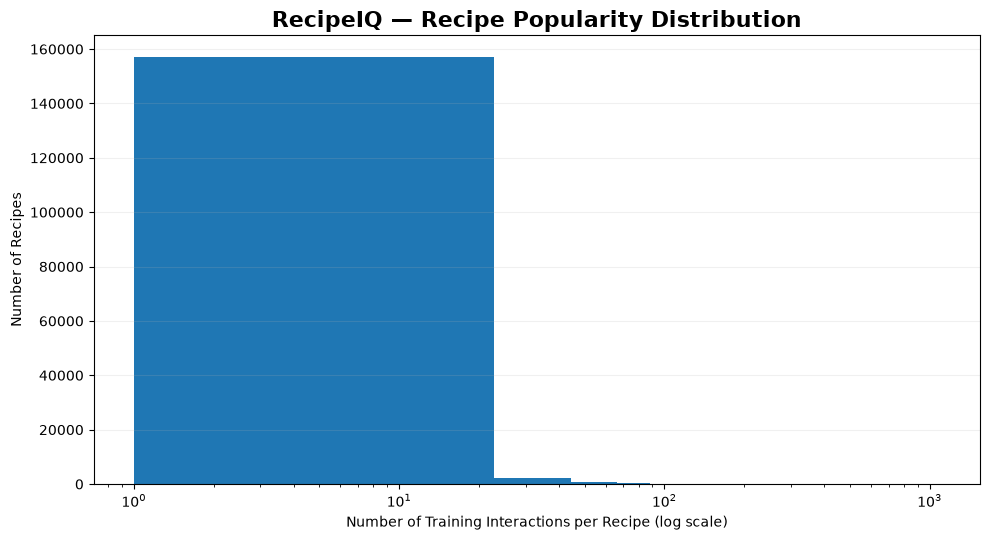

In [87]:
plt.figure(figsize=(10, 5.5))

plt.hist(recipe_popularity, bins=50)

plt.xscale("log")

plt.title(
    "RecipeIQ — Recipe Popularity Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Training Interactions per Recipe (log scale)")
plt.ylabel("Number of Recipes")

plt.grid(axis="y", alpha=0.18)

plt.tight_layout()
plt.show()

In [88]:
n_users = train["u"].nunique()
n_recipes = train["i"].nunique()
n_interactions = len(train)

total_possible = n_users * n_recipes

density = n_interactions / total_possible
sparsity = 1 - density

print("Users:", n_users)
print("Recipes:", n_recipes)
print("Observed interactions:", n_interactions)
print("Possible user-recipe pairs:", total_possible)

print(f"\nInteraction density: {density:.6%}")
print(f"Interaction sparsity: {sparsity:.6%}")

Users: 25076
Recipes: 160901
Observed interactions: 698901
Possible user-recipe pairs: 4034753476

Interaction density: 0.017322%
Interaction sparsity: 99.982678%


In [89]:
popularity_sorted = recipe_popularity.sort_values(ascending=False)

total_interactions = popularity_sorted.sum()

for pct in [1, 5, 10]:
    n = max(1, int(len(popularity_sorted) * pct / 100))
    interactions_top = popularity_sorted.head(n).sum()
    
    print(
        f"Top {pct}% of recipes account for "
        f"{interactions_top / total_interactions:.2%} "
        f"of training interactions"
    )

Top 1% of recipes account for 21.26% of training interactions
Top 5% of recipes account for 40.38% of training interactions
Top 10% of recipes account for 52.05% of training interactions


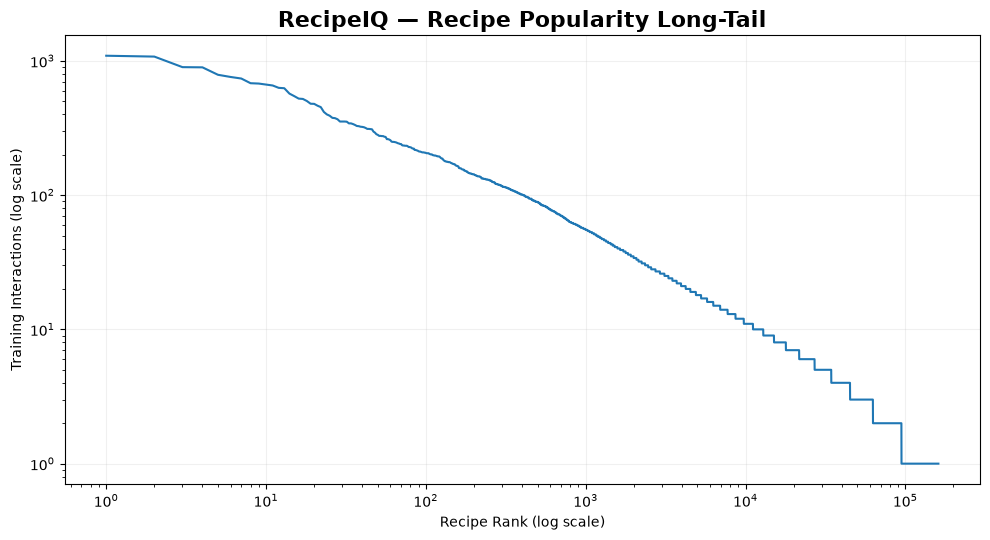

In [90]:
plt.figure(figsize=(10, 5.5))

plt.plot(
    range(1, len(popularity_sorted) + 1),
    popularity_sorted.values
)

plt.xscale("log")
plt.yscale("log")

plt.title(
    "RecipeIQ — Recipe Popularity Long-Tail",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Recipe Rank (log scale)")
plt.ylabel("Training Interactions (log scale)")

plt.grid(alpha=0.18)

plt.tight_layout()
plt.show()

# Phase 1.2: Feature Engineering

In [91]:
recipe_features = raw_recipes[["id", "minutes", "n_ingredients", "n_steps"]].copy()

recipe_features.head()

,id,minutes,n_ingredients,n_steps
0,137739,55,7,11
1,31490,30,6,9
2,112140,130,13,6
3,59389,45,11,11
4,44061,190,8,5


In [92]:
recipe_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231637 entries, 0 to 231636
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   id             231637 non-null  int64
 1   minutes        231637 non-null  int64
 2   n_ingredients  231637 non-null  int64
 3   n_steps        231637 non-null  int64
dtypes: int64(4)
memory usage: 7.1 MB


In [93]:
recipe_features["log_minutes"] = np.log1p(
    recipe_features["minutes"]
)

recipe_features["log_n_ingredients"] = np.log1p(
    recipe_features["n_ingredients"]
)

recipe_features["log_n_steps"] = np.log1p(
    recipe_features["n_steps"]
)

In [94]:
recipe_features[
    [
        "minutes",
        "log_minutes",
        "n_ingredients",
        "log_n_ingredients",
        "n_steps",
        "log_n_steps"
    ]
].head(10)

,minutes,log_minutes,n_ingredients,log_n_ingredients,n_steps,log_n_steps
0,55,4.025352,7,2.079442,11,2.484907
1,30,3.433987,6,1.945910,9,2.302585
2,130,4.875197,13,2.639057,6,1.945910
3,45,3.828641,11,2.484907,11,2.484907
4,190,5.252273,8,2.197225,5,1.791759
5,0,0.000000,4,1.609438,4,1.609438
6,15,2.772589,9,2.302585,4,1.609438
7,120,4.795791,22,3.135494,10,2.397895
8,180,5.198497,6,1.945910,8,2.197225
9,70,4.262680,9,2.302585,12,2.564949


In [95]:
recipe_features["complexity_score"] = (
    recipe_features["log_n_ingredients"] +
    recipe_features["log_n_steps"]
)

In [96]:
recipe_features[
    [
        "id",
        "n_ingredients",
        "n_steps",
        "complexity_score"
    ]
].head(10)

,id,n_ingredients,n_steps,complexity_score
0,137739,7,11,4.564348
1,31490,6,9,4.248495
2,112140,13,6,4.584967
3,59389,11,11,4.969813
4,44061,8,5,3.988984
5,5289,4,4,3.218876
6,25274,9,4,3.912023
7,67888,22,10,5.533389
8,70971,6,8,4.143135
9,75452,9,12,4.867534


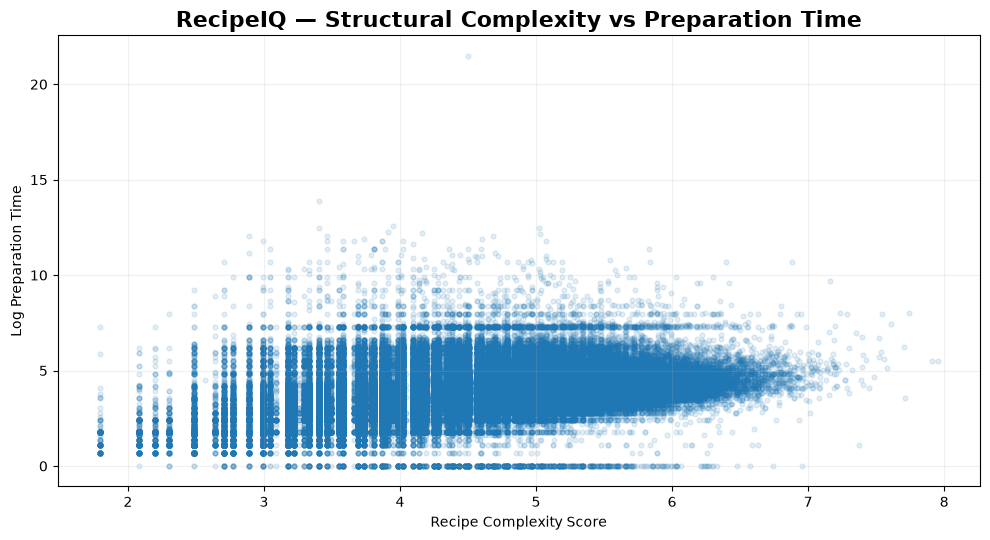

In [97]:
plt.figure(figsize=(10, 5.5))

plt.scatter(
    recipe_features["complexity_score"],
    recipe_features["log_minutes"],
    alpha=0.12,
    s=12
)

plt.title(
    "RecipeIQ — Structural Complexity vs Preparation Time",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Recipe Complexity Score")
plt.ylabel("Log Preparation Time")

plt.grid(alpha=0.18)

plt.tight_layout()
plt.show()

In [98]:
nutrition_data = raw_recipes["nutrition"].apply(
    ast.literal_eval
)

nutrition_data = pd.DataFrame(
    nutrition_data.tolist(),
    columns=[
        "calories",
        "total_fat",
        "sugar",
        "sodium",
        "protein",
        "saturated_fat",
        "carbohydrates"
    ]
)

nutrition_data.head()

,calories,total_fat,sugar,sodium,protein,saturated_fat,carbohydrates
0,51.5,0.0,13.0,0.0,2.0,0.0,4.0
1,173.4,18.0,0.0,17.0,22.0,35.0,1.0
2,269.8,22.0,32.0,48.0,39.0,27.0,5.0
3,368.1,17.0,10.0,2.0,14.0,8.0,20.0
4,352.9,1.0,337.0,23.0,3.0,0.0,28.0


In [99]:
print("Shape:", nutrition_data.shape)
print("Missing values:")
print(nutrition_data.isna().sum())

Shape: (231637, 7)
Missing values:
calories         0
total_fat        0
sugar            0
sodium           0
protein          0
saturated_fat    0
carbohydrates    0
dtype: int64


In [100]:
recipe_features = pd.concat(
    [
        recipe_features.reset_index(drop=True),
        nutrition_data.reset_index(drop=True)
    ],
    axis=1
)

In [101]:
recipe_features.head()

,id,minutes,n_ingredients,n_steps,log_minutes,log_n_ingredients,log_n_steps,complexity_score,calories,total_fat,sugar,sodium,protein,saturated_fat,carbohydrates
0,137739,55,7,11,4.025352,2.079442,2.484907,4.564348,51.5,0.0,13.0,0.0,2.0,0.0,4.0
1,31490,30,6,9,3.433987,1.945910,2.302585,4.248495,173.4,18.0,0.0,17.0,22.0,35.0,1.0
2,112140,130,13,6,4.875197,2.639057,1.945910,4.584967,269.8,22.0,32.0,48.0,39.0,27.0,5.0
3,59389,45,11,11,3.828641,2.484907,2.484907,4.969813,368.1,17.0,10.0,2.0,14.0,8.0,20.0
4,44061,190,8,5,5.252273,2.197225,1.791759,3.988984,352.9,1.0,337.0,23.0,3.0,0.0,28.0


In [102]:
recipe_features.shape

(231637, 15)

In [103]:
nutrition_columns = [
    "calories",
    "total_fat",
    "sugar",
    "sodium",
    "protein",
    "saturated_fat",
    "carbohydrates"
]

for col in nutrition_columns:
    recipe_features[f"log_{col}"] = np.log1p(
        recipe_features[col]
    )

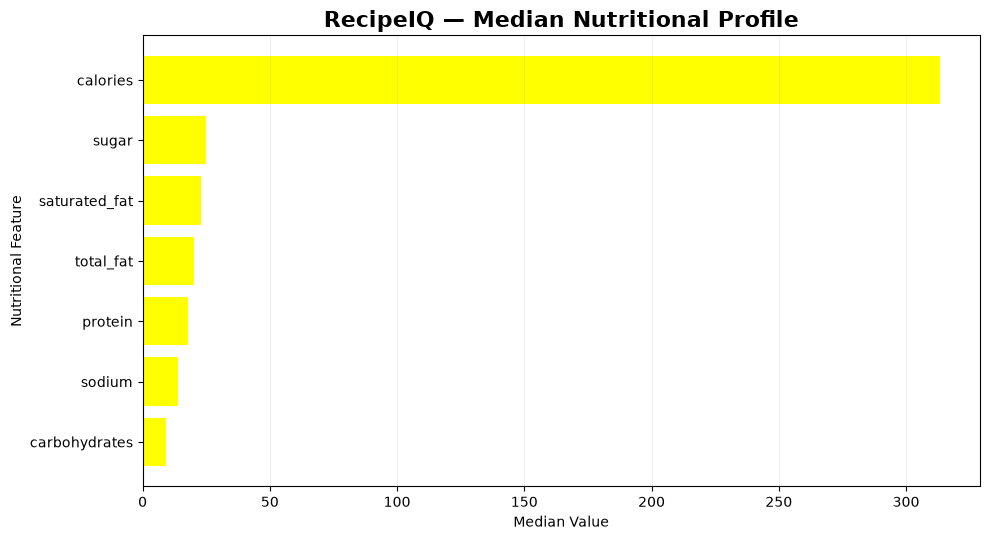

In [104]:
nutrition_medians = recipe_features[nutrition_columns].median().sort_values()

plt.figure(figsize=(10, 5.5))

plt.barh(
    nutrition_medians.index,
    nutrition_medians.values, color='yellow'
)

plt.title(
    "RecipeIQ — Median Nutritional Profile",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Median Value")
plt.ylabel("Nutritional Feature")

plt.grid(axis="x", alpha=0.18)

plt.tight_layout()
plt.show()

In [105]:
recipe_features["ingredient_count"] = raw_recipes[
    "ingredients"
].apply(
    lambda x: len(ast.literal_eval(x))
)

In [106]:
recipe_features["tag_count"] = raw_recipes[
    "tags"
].apply(
    lambda x: len(ast.literal_eval(x))
)

In [107]:
recipe_features[
    [
        "id",
        "n_ingredients",
        "ingredient_count",
        "n_steps",
        "tag_count"
    ]
].head(10)

,id,n_ingredients,ingredient_count,n_steps,tag_count
0,137739,7,7,11,20
1,31490,6,6,9,20
2,112140,13,13,6,9
3,59389,11,11,11,30
4,44061,8,8,5,21
5,5289,4,4,4,25
6,25274,9,9,4,18
7,67888,22,22,10,27
8,70971,6,6,8,21
9,75452,9,9,12,19


In [108]:
print(
    "Ingredient count mismatches:",
    (
        recipe_features["n_ingredients"]
        != recipe_features["ingredient_count"]
    ).sum()
)

Ingredient count mismatches: 0


In [109]:
print("Shape:", recipe_features.shape)

print("\nColumns:")
print(recipe_features.columns.tolist())

print("\nMissing values:")
print(
    recipe_features.isna().sum()
    .sort_values(ascending=False)
)

Shape: (231637, 24)

Columns:
['id', 'minutes', 'n_ingredients', 'n_steps', 'log_minutes', 'log_n_ingredients', 'log_n_steps', 'complexity_score', 'calories', 'total_fat', 'sugar', 'sodium', 'protein', 'saturated_fat', 'carbohydrates', 'log_calories', 'log_total_fat', 'log_sugar', 'log_sodium', 'log_protein', 'log_saturated_fat', 'log_carbohydrates', 'ingredient_count', 'tag_count']

Missing values:
id                   0
minutes              0
ingredient_count     0
log_carbohydrates    0
log_saturated_fat    0
log_protein          0
log_sodium           0
log_sugar            0
log_total_fat        0
log_calories         0
carbohydrates        0
saturated_fat        0
protein              0
sodium               0
sugar                0
total_fat            0
calories             0
complexity_score     0
log_n_steps          0
log_n_ingredients    0
log_minutes          0
n_steps              0
n_ingredients        0
tag_count            0
dtype: int64


In [110]:
recipe_features.describe().T

,count,mean,std,min,25%,50%,75%,max
id,231637.0,222014.708984,1.412066e+05,38.000000,99944.000000,207249.000000,333816.000000,5.377160e+05
minutes,231637.0,9398.546009,4.461963e+06,0.000000,20.000000,40.000000,65.000000,2.147484e+09
n_ingredients,231637.0,9.051153,3.734796e+00,1.000000,6.000000,9.000000,11.000000,4.300000e+01
n_steps,231637.0,9.765499,5.995128e+00,0.000000,6.000000,9.000000,12.000000,1.450000e+02
log_minutes,231637.0,3.676370,1.089506e+00,0.000000,3.044522,3.713572,4.189655,2.148756e+01
log_n_ingredients,231637.0,2.237176,3.839859e-01,0.693147,1.945910,2.302585,2.484907,3.784190e+00
log_n_steps,231637.0,2.237836,5.337254e-01,0.000000,1.945910,2.302585,2.564949,4.983607e+00
complexity_score,231637.0,4.475013,7.844657e-01,1.791759,3.988984,4.499810,5.030438,7.955074e+00
calories,231637.0,473.942425,1.189711e+03,0.000000,174.400000,313.400000,519.700000,4.343602e+05
total_fat,231637.0,36.080700,7.779884e+01,0.000000,8.000000,20.000000,41.000000,1.718300e+04


In [111]:
feature_path = DATA_DIR / "recipe_features_phase1.csv"

recipe_features.to_csv(
    feature_path,
    index=False
)

print("Saved:", feature_path)
print("Shape:", recipe_features.shape)

Saved: C:\Users\Mastm\OneDrive\Documents\AnC Essentials\RecipeIQ\recipe_features_phase1.csv
Shape: (231637, 24)


In [156]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path(
    r"C:\Users\Mastm\OneDrive\Documents\AnC Essentials\RecipeIQ"
)

OUTPUT_FILE = DATA_DIR / "recipe_features_phase1.csv"

# Validate before saving
assert "id" in recipe_features.columns, "Recipe ID column is missing."
assert recipe_features["id"].notna().all(), "Missing recipe IDs found."
assert recipe_features["id"].is_unique, "Duplicate recipe IDs found."

# Save the feature table
recipe_features.to_csv(OUTPUT_FILE, index=False)

# Read it back to verify the saved file
saved_features = pd.read_csv(OUTPUT_FILE)

print("Saved file:", OUTPUT_FILE)
print("Original shape:", recipe_features.shape)
print("Saved shape:", saved_features.shape)
print("IDs unique:", saved_features["id"].is_unique)
print("Missing IDs:", saved_features["id"].isna().sum())
print("Export verified:", recipe_features.shape == saved_features.shape)

Saved file: C:\Users\Mastm\OneDrive\Documents\AnC Essentials\RecipeIQ\recipe_features_phase1.csv
Original shape: (231637, 24)
Saved shape: (231637, 24)
IDs unique: True
Missing IDs: 0
Export verified: True


## Phase 1 — Data Exploration and Feature Engineering

### Objective

Understand the Food.com recipe and interaction datasets, identify data-quality issues, explore user–recipe interaction patterns, and create structured recipe features for the recommendation system.

### Work completed

* Inspected the raw recipe and user–recipe interaction data.
* Examined user activity and recipe popularity distributions.
* Analysed rating distributions and the long-tail nature of recipe popularity.
* Parsed nutritional information into separate numerical features.
* Engineered preparation-time, ingredient-count, step-count, log-transformed and recipe-complexity features.
* Created a nutritional profile and ingredient/tag-count features.
* Validated recipe IDs, missing values and duplicate IDs.
* Exported the engineered recipe feature table as `recipe_features_phase1.csv`.

### Key observations

* User activity is highly uneven: some users interact with many recipes, while many users interact with relatively few.
* Recipe popularity follows a long-tail distribution: a small group of recipes receives a large share of interactions.
* Ratings are imbalanced, with high ratings making up most interactions in the supplied training data.
* Recipe preparation time, ingredient count, step count and nutrition provide useful descriptive information about recipes.

### Limitations

* The interaction data is sparse relative to all possible user–recipe pairs.
* Popularity and rating imbalance can bias a recommendation model toward frequently interacted-with recipes.
* Log transformations reduce the influence of extreme numerical values but do not automatically remove invalid observations.
* Engineered numerical features describe recipe characteristics; they do not independently capture a user's preferences.
* Recipe IDs and processed model indices must be kept distinct and mapped consistently.

### Output

`recipe_features_phase1.csv`

This file will supply recipe-level numerical features to later recommendation-system experiments. Model training, negative sampling, hyperparameter tuning and final ranking evaluation belong to Phase 2.
